# Pre Processing 

In [247]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [248]:
## loading libraries essential for feature engineering


In [249]:
# loading the dataset
import joblib
df = joblib.load('/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/artifacts/df_EDA_cleaned.pkl')

In [250]:
df.head()

,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,type,listed_in(city)
0,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [251]:
df = df.drop(columns='cuisines',axis=1)

In [252]:
df.sample(3)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,listed_in(city)
686,0,0,3.4,51,Basavanagudi,Quick Bites,350,Dine-out,Banashankari
36687,0,0,3.7,15,New BEL Road,Quick Bites,200,Dine-out,New BEL Road
23704,1,0,5.0,0,Koramangala 1st Block,"Takeaway, Delivery",450,Dine-out,Koramangala 4th Block


In [253]:
locs = df.location.unique()

col_list = ['online_order', 'book_table', 'location', 'rest_type', 'type', 'listed_in(city)']

for col in col_list:
    feature = df[col].astype('category')
    dict_val = dict(enumerate(feature.cat.categories))
    print(col, dict_val)

online_order {0: 0, 1: 1}
book_table {0: 0, 1: 1}
location {0: 'BTM', 1: 'Banashankari', 2: 'Banaswadi', 3: 'Bannerghatta Road', 4: 'Basavanagudi', 5: 'Basaveshwara Nagar', 6: 'Bellandur', 7: 'Bommanahalli', 8: 'Brigade Road', 9: 'Brookefield', 10: 'CV Raman Nagar', 11: 'Central Bangalore', 12: 'Church Street', 13: 'City Market', 14: 'Commercial Street', 15: 'Cunningham Road', 16: 'Domlur', 17: 'East Bangalore', 18: 'Ejipura', 19: 'Electronic City', 20: 'Frazer Town', 21: 'HBR Layout', 22: 'HSR', 23: 'Hebbal', 24: 'Hennur', 25: 'Hosur Road', 26: 'Indiranagar', 27: 'Infantry Road', 28: 'JP Nagar', 29: 'Jalahalli', 30: 'Jayanagar', 31: 'Jeevan Bhima Nagar', 32: 'KR Puram', 33: 'Kaggadasapura', 34: 'Kalyan Nagar', 35: 'Kammanahalli', 36: 'Kanakapura Road', 37: 'Kengeri', 38: 'Koramangala', 39: 'Koramangala 1st Block', 40: 'Koramangala 2nd Block', 41: 'Koramangala 3rd Block', 42: 'Koramangala 4th Block', 43: 'Koramangala 5th Block', 44: 'Koramangala 6th Block', 45: 'Koramangala 7th Block',

In [254]:
df = df.rename(columns={'listed_in(city)' : 'city'})

In [255]:
df.head()

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city
0,1,1,4.1,775,Banashankari,Casual Dining,800,Buffet,Banashankari
1,1,0,4.1,787,Banashankari,Casual Dining,800,Buffet,Banashankari
2,1,0,3.8,918,Banashankari,"Cafe, Casual Dining",800,Buffet,Banashankari
3,0,0,3.7,88,Banashankari,Quick Bites,300,Buffet,Banashankari
4,0,0,3.8,166,Basavanagudi,Casual Dining,600,Buffet,Banashankari


### Categorical Features

In [256]:
# Converting columns to catagorical variables 
def convert_cat(df, col_list): 
  df_temp = pd.DataFrame() 
  df_temp = df
  col_list = col_list
  
  for col in col_list:
      df_temp[col] = df_temp[col].astype('category')
      df_temp[col] = df_temp[col].cat.codes
      
  return df_temp

col_list = ['online_order', 'book_table', 'location', 'rest_type', 'type', 'city']
df_clean = convert_cat(df, col_list)

In [257]:
df_clean.head(2)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city
0,1,1,4.1,775,1,24,800,0,1
1,1,0,4.1,787,1,24,800,0,1


In [258]:
df_clean.head(2)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city
0,1,1,4.1,775,1,24,800,0,1
1,1,0,4.1,787,1,24,800,0,1


array([[<Axes: title={'center': 'online_order'}>,
        <Axes: title={'center': 'book_table'}>,
        <Axes: title={'center': 'rate'}>],
       [<Axes: title={'center': 'votes'}>,
        <Axes: title={'center': 'location'}>,
        <Axes: title={'center': 'rest_type'}>],
       [<Axes: title={'center': 'approx_cost'}>,
        <Axes: title={'center': 'type'}>,
        <Axes: title={'center': 'city'}>]], dtype=object)

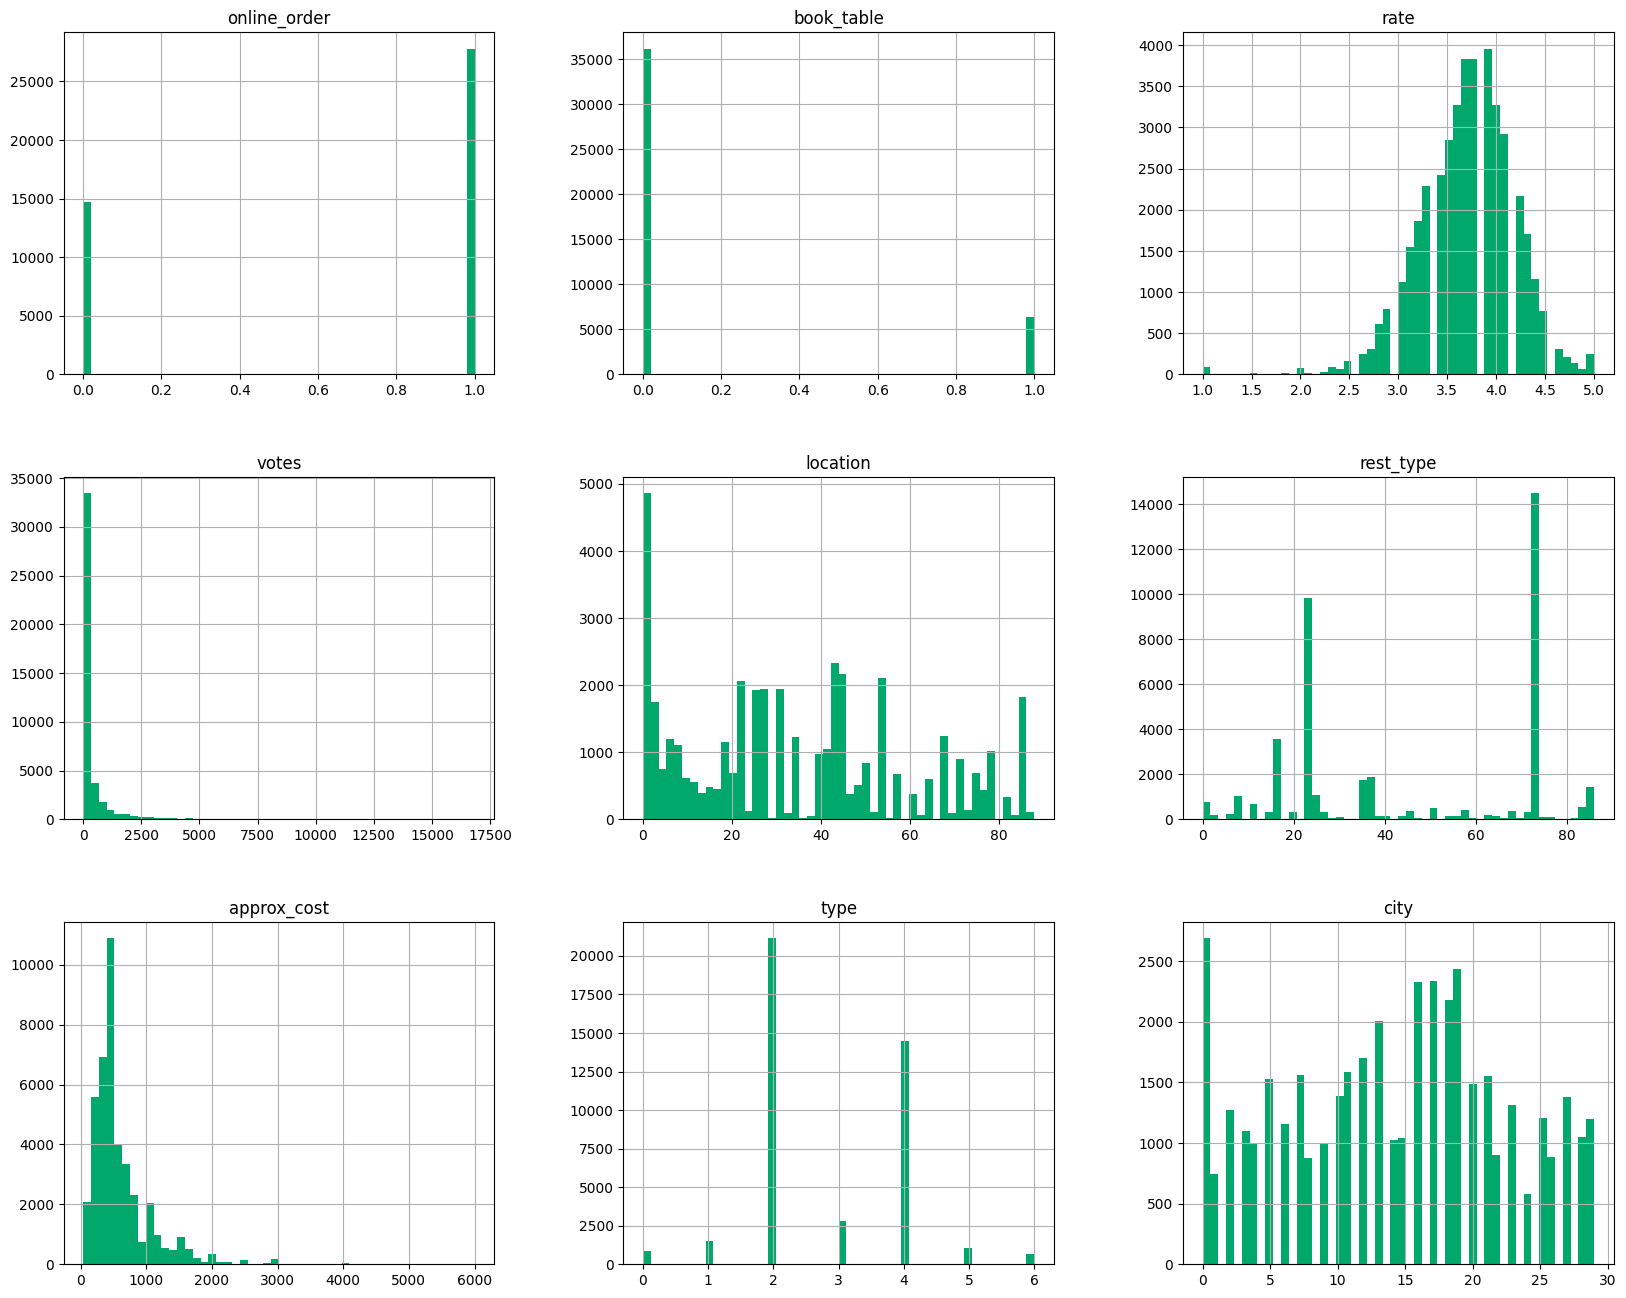

In [259]:
df_clean.hist(bins = 50, figsize=(20,16), color = '#00A86B') 


In [260]:
df_clean.online_order.value_counts()

online_order
1    27804
0    14719
Name: count, dtype: int64

## Outliers Detection

In [261]:
import scipy
import scipy.stats as stats

def outlier_cols(x): 
    n = len(x)
    mean_x = np.mean(x)
    sd_x = np.std(x)
    numerator = max(abs(x-mean_x))
    g_calculated = numerator/sd_x
    t_value = stats.t.ppf(1 - 0.05 / (2 * n), n - 2)
    g_critical = ((n - 1) * np.sqrt(np.square(t_value))) / (np.sqrt(n) * np.sqrt(n - 2 + np.square(t_value)))
    return col if (g_critical) < g_calculated else 0

- Grubbs’ Test is a statistical test used to detect a single outlier in a normally distributed dataset.

- It tests whether the most extreme value (either maximum or minimum) in a dataset is an outlier compared to the rest

In [262]:
cols_with_outliers = []
for col in df_clean.columns:
    outlier_col = outlier_cols(df_clean[col])
    cols_with_outliers.append(outlier_col)

while (cols_with_outliers.count(0)):
    cols_with_outliers.remove(0)
print('Columns with outliers are: {}'.format(cols_with_outliers) )

Columns with outliers are: ['rate', 'votes', 'approx_cost']


### Using EDA Tools:-

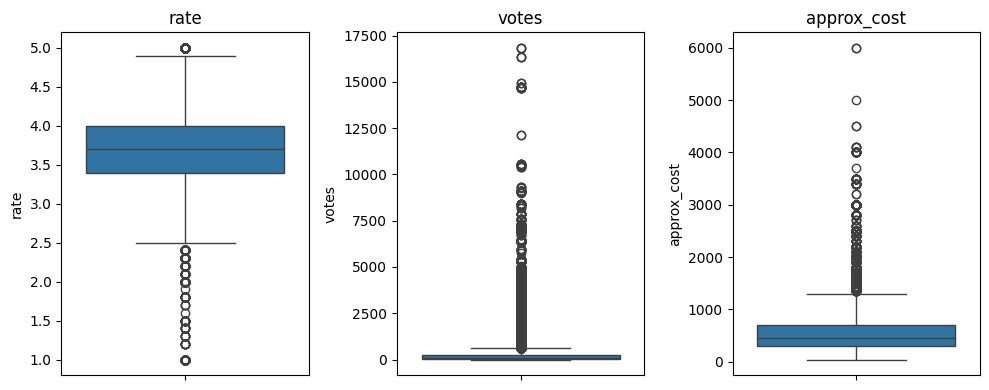

In [263]:

numeric_cols = ['rate', 'votes', 'approx_cost']
plt.figure(figsize=(10,4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df_clean[col])
    plt.title(col)
plt.tight_layout()
plt.show()


- Clearly, columns = ['rate', 'approx_cost', 'votes'] has outliers 

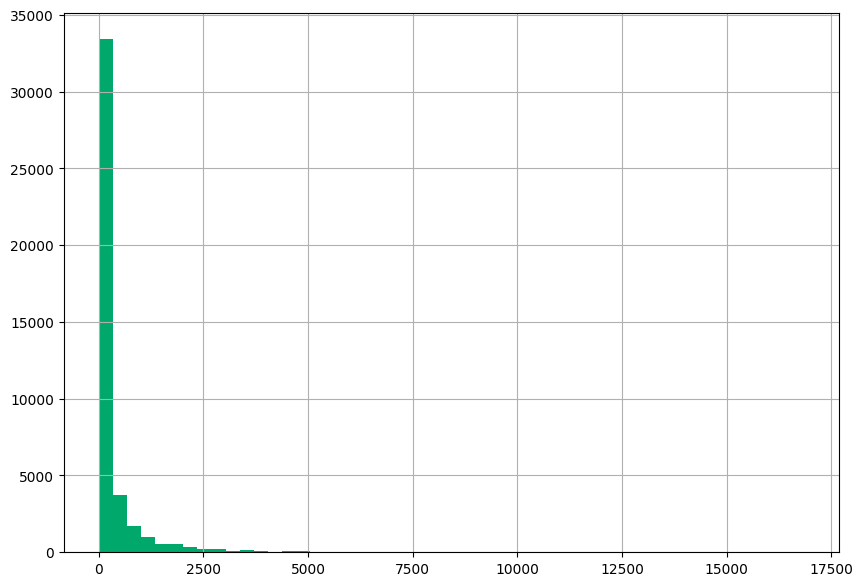

In [264]:
# Plotting histogram
%matplotlib inline
df_clean['votes'].hist(bins = 50, figsize=(10,7), color = '#00A86B') 
plt.show()

In [265]:
def grubbs_test(x):
    n = len(x)
    mean_x = np.mean(x)
    sd_x = np.std(x)
    numerator = max(abs(x-mean_x))
    g_calculated = numerator/sd_x
    print("Grubbs Calculated Value:",g_calculated)
    t_value = stats.t.ppf(1 - 0.05 / (2 * n), n - 2)
    g_critical = ((n - 1) * np.sqrt(np.square(t_value))) / (np.sqrt(n) * np.sqrt(n - 2 + np.square(t_value)))
    print("Grubbs Critical Value:",g_critical)
    if g_critical > g_calculated:
        print("From grubbs_test we observe that calculated value is lesser than critical value, Accept null hypothesis and conclude that there is no outlier\n")
    else:
        print("From grubbs_test we observe that calculated value is greater than critical value, Reject null hypothesis and conclude that there is an outliers\n")

- Since the data is skewed, we will apply "log transform" to reduce skewness

In [266]:
df_clean['votes_log'] = np.log1p(df_clean['votes'])

In [267]:
df_clean.head(2)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city,votes_log
0,1,1,4.1,775,1,24,800,0,1,6.654153
1,1,0,4.1,787,1,24,800,0,1,6.669498


- Setting up "cap" anything above the 99th percentile:

In [273]:
df_clean['votes'].quantile(0.99)

np.float64(4134.599999999977)

In [269]:
# Removing outliers
cut_off = 4134
for i in df_clean['votes_log']:
    if i >= cut_off:
        df_clean['votes_log'] = df_clean['votes_log'].replace(i, cut_off)


In [270]:
df_clean.head(2)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city,votes_log
0,1,1,4.1,775,1,24,800,0,1,6.654153
1,1,0,4.1,787,1,24,800,0,1,6.669498


In [271]:
grubbs_test(df_clean['votes_log'])

Grubbs Calculated Value: 2.952405715007019
Grubbs Critical Value: 4.85902075952334
From grubbs_test we observe that calculated value is lesser than critical value, Accept null hypothesis and conclude that there is no outlier

